In [1]:
import pandas as pd
import numpy as np
import re, html

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle


In [2]:
os.makedirs("model", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [3]:
df = pd.read_csv(r"C:\Users\ASUS\Documents\archive (4)\IMDB Dataset.csv")
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


EDA

Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB

Missing values per column:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Label distribution counts:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Label distribution percent:
sentiment
1    0.5
0    0.5
Name: proportion, dtype: float64


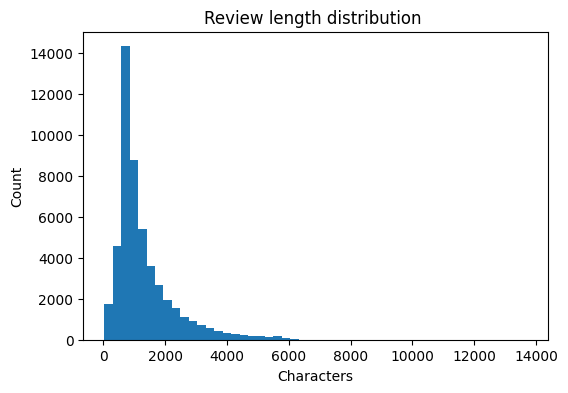

In [4]:
print('Shape:', df.shape)
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution counts:")
print(df['sentiment'].value_counts())
print("\nLabel distribution percent:")
print(df['sentiment'].value_counts(normalize=True).round(4))

df['review_len'] = df['review'].astype(str).str.len()
plt.figure(figsize=(6,4))
plt.hist(df['review_len'], bins=50)
plt.title('Review length distribution ')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.show()


In [5]:
def clean_text(text: str) -> str:
    text = str(text)
    text = html.unescape(text)
    text = text.lower()
  
    text = re.sub(r'<br\s*/?>', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)
df[['review','review_clean']].head()


,review,review_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [6]:
analyzer = SentimentIntensityAnalyzer()

def extract_features(text):
    vader = analyzer.polarity_scores(text)
    blob = TextBlob(text).sentiment.polarity
    return pd.Series([vader['neg'], vader['neu'], vader['pos'], vader['compound'], blob])

df[['vader_neg','vader_neu','vader_pos','vader_compound','textblob_polarity']] = df['review_clean'].apply(extract_features)


Training and test splitting 

In [15]:
y = df['sentiment']

X = df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'textblob_polarity']]
X_text = df["review_clean"]
X_temp, X_test, X_temp_text, X_test_text, y_temp, y_test = train_test_split(
    X, X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_temp, X_temp_text, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


mlp.fit(X_train_scaled, y_train)


mlp_preds = mlp.predict(X_test_scaled)

Training our MLP

In [16]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [17]:

train_proba = mlp.predict_proba(X_train)[:, 1]
val_proba   = mlp.predict_proba(X_val)[:, 1]
test_proba  = mlp.predict_proba(X_test)[:, 1]

y_train_pred = (train_proba >= 0.5).astype(int)
val_pred     = (val_proba   >= 0.5).astype(int)
y_test_pred  = (test_proba  >= 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, val_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Test Accuracy:", test_acc)

print("\nClassification Report (TEST):\n")
print(classification_report(y_test, y_test_pred))

with open("results/metrics.txt", "w") as f:
    f.write(f"Training Accuracy: {train_acc}\n")
    f.write(f"Validation Accuracy: {val_acc}\n")
    f.write(f"Test Accuracy: {test_acc}\n\n")
    f.write(classification_report(y_test, y_test_pred))


Training Accuracy: 0.7755333333333333
Validation Accuracy: 0.7777
Test Accuracy: 0.7784

Classification Report (TEST):

              precision    recall  f1-score   support

           0       0.77      0.79      0.78      5000
           1       0.78      0.77      0.78      5000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



Plotting the Confusion Matrix 

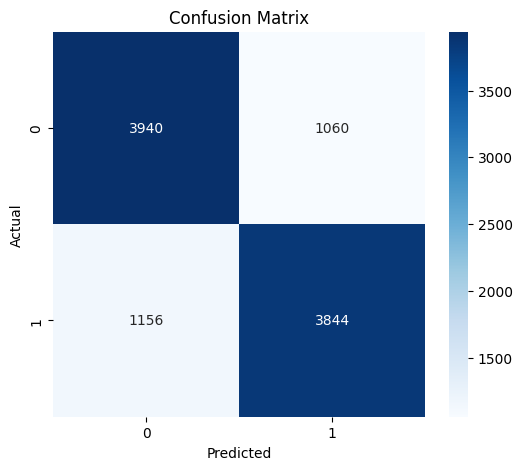

In [18]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("results/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


Plotting the loss Curve

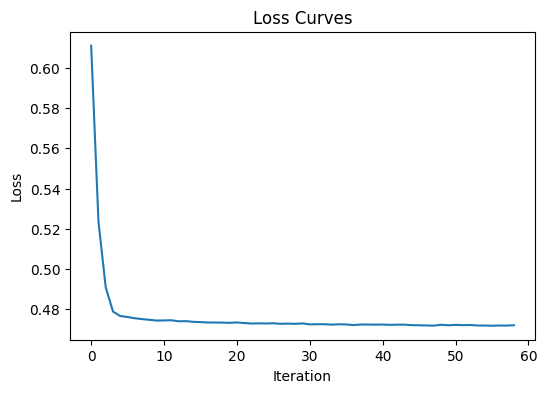

In [19]:
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_)
plt.title("Loss Curves")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.savefig("results/loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()


In [20]:


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)   # ⚠️ IMPORTANT: use TEXT, not features

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
LSTM

In [21]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop]
)

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 269s 553ms/step - accuracy: 0.6061 - loss: 0.6393 - val_accuracy: 0.6605 - val_loss: 0.6194
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 281s 600ms/step - accuracy: 0.6872 - loss: 0.5628 - val_accuracy: 0.6733 - val_loss: 0.5605
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 313s 580ms/step - accuracy: 0.7764 - loss: 0.4847 - val_accuracy: 0.8340 - val_loss: 0.4117
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 367s 676ms/step - accuracy: 0.8534 - loss: 0.3598 - val_accuracy: 0.8530 - val_loss: 0.3728
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 285s 607ms/step - accuracy: 0.8871 - loss: 0.2859 - val_accuracy: 0.8531 - val_loss: 0.3590
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 357s 681ms/step - accuracy: 0.9206 - loss: 0.2150 - val_accuracy: 0.8634 - val_loss: 0.3670
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 290s 618ms/step - accuracy: 0.9397 - loss: 0.1705 - val_accuracy: 0.8646 - val_loss: 0.3942


In [22]:
from sklearn.metrics import accuracy_score, classification_report

lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))
print(classification_report(y_test, lstm_preds))

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step
LSTM Accuracy: 0.8606
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      5000
           1       0.86      0.85      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [23]:


from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=8,
    batch_size=64,
    callbacks=[early_stop]
)

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 276ms/step - accuracy: 0.8023 - loss: 0.4117 - val_accuracy: 0.8864 - val_loss: 0.2663
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 264ms/step - accuracy: 0.9352 - loss: 0.1763 - val_accuracy: 0.9010 - val_loss: 0.2497
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 302ms/step - accuracy: 0.9868 - loss: 0.0500 - val_accuracy: 0.8960 - val_loss: 0.3030
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - accuracy: 0.9989 - loss: 0.0084 - val_accuracy: 0.8958 - val_loss: 0.3723


In [28]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# MLP
mlp_preds = mlp.predict(X_test_scaled)
mlp_acc = accuracy_score(y_test, mlp_preds)

# LSTM
lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int).ravel()
lstm_acc = accuracy_score(y_test, lstm_preds)


results = [
    ["MLP Baseline", mlp_acc, f1_score(y_test, mlp_preds)],
    ["LSTM", lstm_acc, f1_score(y_test, lstm_preds)]
]

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])
print(results_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step
          Model  Accuracy        F1
0  MLP Baseline    0.7823  0.783491
1          LSTM    0.8606  0.859787


Saving the  model

In [12]:
with open("model/best_model.pkl", "wb") as f:
    pickle.dump(mlp, f)


getting submiossion.csv

In [13]:
all_proba = mlp.predict_proba(X)[:, 1]
all_pred  = (all_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "review": df["review"],
    "predicted_sentiment": all_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()



,review,predicted_sentiment
0,One of the other reviewers has mentioned that ...,0
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


Discussion
. the dataset has been split into: 60% training set, 20% validation test and 20% test set 
.The reslts showcast an accuracy of 77.32% for both training and test with a an accuracy of 77.36% for validation
.These results above showcast thta the perfirmance is reasinable yet limited. A limitatipn that is due to the polarity scores used that do not capture all aspecys like sarcasm for exemple


In [33]:
lstm_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": lstm_preds
})

lstm_results_df.to_csv("lstm_results.csv", index=False)

In [34]:
cnn_preds = (cnn_model.predict(X_test_pad) > 0.5).astype(int).ravel()
cnn_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": cnn_preds
})

cnn_results_df.to_csv("cnn_results.csv", index=False)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


In [35]:
mlp_results_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": mlp_preds
})

mlp_results_df.to_csv("mlp_results.csv", index=False)